# Point-wise profile confidence bands

Compute, save and browse **point-wise confidence intervals** of the recovered
flux $x(v_{\min})$.

## Method (port of kyphys-creator/neutrinoAnalysis)

At each scanned $v_{\min}$ index $j$:

1. **Fix** the flux step $x_j$ at a trial value $v$ and refit everything else
   → $\chi^2_{\rm fixed}$. The difference from the free fit's
   $\chi^2_{\rm free}$ is the observed $\Delta\chi^2_{\rm obs}$.
2. Generate Poisson pseudo-experiments from the **fixed-fit model**, refit each
   pseudo-dataset both free and fixed, and build the $\Delta\chi^2$
   distribution. Its CL quantile is the cutoff (no $\chi^2(1)$ assumption —
   the monotone non-negative constraints make the true distribution
   non-trivial).
3. $v$ is inside the band iff $\Delta\chi^2_{\rm obs} <$ cutoff. The edges are
   located by outward bracketing + geometric bisection (common random
   numbers).

Implementation:
[`quantum_sensor.statistics.find_confidence_band`](src/quantum_sensor/statistics.py).
Solver: CLARABEL (~40x faster than OSQP on this QP, $\chi^2$ agreement ~3e-5).

## Outputs (inside each run folder `results/<DET>/bkg-<bkg>/<config>/`)

| file | contents |
|---|---|
| `flux_profile_band.csv` | summary table: `vmin_mid, best_fit, lo68, hi68, lo95, hi95` (natural units) |
| `band/band_idx*.json` | full record **per scanned point** (cutoffs, evaluation counts). One file per point, so points can be added, recomputed or diffed individually |
| `flux_profile_band.pdf` | figure: eta + best-fit staircase + shaded bands (y-axis capped so the best fit stays readable) |

Reload with `load_pointwise_band(run_dir(a))` (§4).

**Run time**: ~30 s – 3 min per point × ~12–30 points per configuration.
§3 is the heavy full computation — try the single-point §2 first.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig
from quantum_sensor.statistics import (find_confidence_band, pointwise_band,
                                       save_pointwise_band, load_pointwise_band)
from quantum_sensor.plotting import (plot_flux_with_pointwise_bands,
                                     run_dir, RESULTS_DIR, ETA_TO_CM_INV)

LEVELS = (0.68, 0.954)

# Unit convention: the pipeline, CSV and JSON are all in natural units
# (GeV-based, dimension 1/length). Only the DISPLAY multiplies by
# ETA_TO_CM_INV (~5.05e4) to get physical cm^-1 (same convention as plotting).


def band_table(bands):
    """Readable table of pointwise_band results: physical units (cm^-1) plus
    relative errors."""
    C = ETA_TO_CM_INV
    rows = []
    for b in bands:
        lo68, hi68 = b['band'][LEVELS[0]]
        lo95, hi95 = b['band'][LEVELS[1]]
        f = b['best_fit']
        rows.append({
            'index': b['index'], 'vmin [km/s]': round(b['vmin_mid'], 1),
            'best fit [cm^-1]': f * C,
            'lo68 [cm^-1]': lo68 * C, 'hi68 [cm^-1]': hi68 * C,
            'lo95 [cm^-1]': lo95 * C, 'hi95 [cm^-1]': hi95 * C,
            '-68%': f'-{(1 - lo68 / f) * 100:.0f}%' if f > 0 else '-',
            '+68%': f'+{(hi68 / f - 1) * 100:.0f}%' if f > 0 and np.isfinite(hi68) else '-',
            'evals': b['n_evaluations'],
        })
    return pd.DataFrame(rows)


def save_band_products(a, bands):
    """Save the summary CSV, the per-point JSONs under band/, and the PDF."""
    out = run_dir(a)
    out.mkdir(parents=True, exist_ok=True)
    table = np.array([[b['vmin_mid'], b['best_fit'],
                       b['band'][LEVELS[0]][0], b['band'][LEVELS[0]][1],
                       b['band'][LEVELS[1]][0], b['band'][LEVELS[1]][1]]
                      for b in bands])
    np.savetxt(out / 'flux_profile_band.csv', table, delimiter=',', comments='',
               header='vmin_mid,best_fit,lo68,hi68,lo95,hi95')
    band_dir = save_pointwise_band(a, bands)   # band/band_idx*.json (one per point)
    plot_flux_with_pointwise_bands(a, bands)
    print(f'saved: flux_profile_band.csv / {len(bands)} json under {band_dir.name}/ / pdf  ({out})')


## 1. Choose a configuration and fit

`material` (`'Al'` = TES / `'TiN'` = MKID), `q` (`'0'` = heavy mediator /
`'2'` = light), `mass` (`'1'` = 10 MeV / `'2'` = 100 MeV / `'3'` = 1 GeV),
`nbins` (Al: 5/10, TiN: 5/9).


In [9]:
CONFIG = RunConfig(material='TiN', q='0', mass='2', nbins=5,
                   eta='Halo', background='none')

a = DarkMatterQuantumAnalysis(CONFIG)
a.optimize()

print(f'config        : {CONFIG}')
print(f'v_min columns : {a.n_vmin}  (window {a.vmin_mid[0]:.0f}-{a.vmin_mid[-1]:.0f} km/s)')
print(f'energy bins   : {a.n_ebins}')
print(f'counts per bin: {np.array2string(a.observed, precision=1)}')
print(f'best-fit chi2 : {a.result.fun:.2e}  (self-consistent -> ~0)')


config        : RunConfig(material='TiN', q='0', mass='2', nbins=5, eta='Halo', disk_fraction=None, background='none', run=None)
v_min columns : 286  (window 17-245 km/s)
energy bins   : 5
counts per bin: [129.3 390.5 574.9 747.4 905.3]
best-fit chi2 : 0.00e+00  (self-consistent -> ~0)


## 2. Try a single point first (quick)

A single mid-window point with the production MC settings. Use this to gauge
the cost and the band width before launching the full scan in §3.


In [ ]:
idx = a.n_vmin // 3   # a point in the middle of the window

# Pseudo-experiment fits run on a thread pool (n_jobs=8 default; CLARABEL
# releases the GIL, ~3.5x). Run time ~ n_pseudo_edge x #evaluations(~10-20) x ~15ms:
# n_pseudo_edge=500 -> ~1-3 min per point.
b1 = find_confidence_band(a, index=idx, levels=LEVELS,
                          num_pseudo=50, n_pseudo_edge=500, rel_tol=0.02)

f = b1['best_fit']
print(f"v_min = {b1['vmin_mid']:.0f} km/s")
print(f'best fit  = {f * ETA_TO_CM_INV:.3g} cm^-1   (input eta = {a.eta[idx] * ETA_TO_CM_INV:.3g} cm^-1)')
for lv in LEVELS:
    lo, hi = b1['band'][lv]
    print(f'{lv*100:.0f}% : [{lo * ETA_TO_CM_INV:.3g}, {hi * ETA_TO_CM_INV:.3g}] cm^-1'
          + (f'   (-{(1-lo/f)*100:.0f}% / +{(hi/f-1)*100:.0f}%)' if f > 0 else ''))
print('(pipeline/CSV/JSON stay in natural units; only the display converts via ETA_TO_CM_INV)')


## 3. Full band (production settings, ~30-60 min per configuration)

By default the scan takes the "window of positive flux" and samples it at
log-spaced indices (denser at low velocity). Use `n_indices=` to change the
count or `indices=[...]` to pick locations explicitly.

If this configuration is already computed, just load it in §4 instead.


[1/25] idx 0 (v=17 km/s) best 8.28e-32  0.68: [7.82e-32, inf]  (33 evals)
[2/25] idx 1 (v=18 km/s) best 8.28e-32  0.68: [7.82e-32, 1.61e-29]  (38 evals)
[3/25] idx 2 (v=19 km/s) best 8.28e-32  0.68: [7.82e-32, 3.53e-30]  (31 evals)
[4/25] idx 3 (v=20 km/s) best 8.28e-32  0.68: [7.82e-32, 8.88e-31]  (31 evals)
[5/25] idx 4 (v=21 km/s) best 8.28e-32  0.68: [7.82e-32, 4.11e-31]  (29 evals)
[6/25] idx 5 (v=21 km/s) best 8.28e-32  0.68: [7.82e-32, 2.41e-31]  (22 evals)
[7/25] idx 6 (v=22 km/s) best 8.28e-32  0.68: [7.82e-32, 1.72e-31]  (21 evals)
[8/25] idx 7 (v=23 km/s) best 8.28e-32  0.68: [7.82e-32, 1.4e-31]  (22 evals)
[9/25] idx 9 (v=25 km/s) best 8.28e-32  0.68: [7.82e-32, 1.1e-31]  (20 evals)
[10/25] idx 11 (v=26 km/s) best 8.28e-32  0.68: [7.82e-32, 9.82e-32]  (20 evals)
[11/25] idx 14 (v=29 km/s) best 8.18e-32  0.68: [7.83e-32, 9.11e-32]  (19 evals)
[12/25] idx 17 (v=31 km/s) best 8.18e-32  0.68: [7.83e-32, 9e-32]  (19 evals)
[13/25] idx 20 (v=33 km/s) best 8.18e-32  0.68: [7.83e-3

,index,vmin [km/s],best fit [cm^-1],lo68 [cm^-1],hi68 [cm^-1],lo95 [cm^-1],hi95 [cm^-1],-68%,+68%,evals
0,0,17.4,4.180242e-27,3.948638e-27,inf,3.849831e-27,inf,-6%,-,33
1,1,18.2,4.180242e-27,3.948638e-27,8.113192e-25,3.801358e-27,1.819695e-24,-6%,+19308%,38
2,2,19.0,4.180242e-27,3.948638e-27,1.784189e-25,3.801358e-27,4.196463e-25,-6%,+4168%,31
3,3,19.8,4.180242e-27,3.948638e-27,4.487097e-26,3.801358e-27,1.011197e-25,-6%,+973%,31
4,4,20.6,4.180242e-27,3.948638e-27,2.074794e-26,3.801358e-27,4.409554e-26,-6%,+396%,29
5,5,21.4,4.180242e-27,3.948638e-27,1.219554e-26,3.801358e-27,2.102925e-26,-6%,+192%,22
6,6,22.2,4.180242e-27,3.948638e-27,8.689820e-27,3.801358e-27,1.397551e-26,-6%,+108%,21
7,7,23.0,4.180242e-27,3.948638e-27,7.050399e-27,3.849831e-27,1.091596e-26,-6%,+69%,22
8,9,24.6,4.180242e-27,3.948638e-27,5.559354e-27,3.801358e-27,7.827108e-27,-6%,+33%,20
9,11,26.2,4.180242e-27,3.948638e-27,4.960194e-27,3.801358e-27,6.390807e-27,-6%,+19%,20


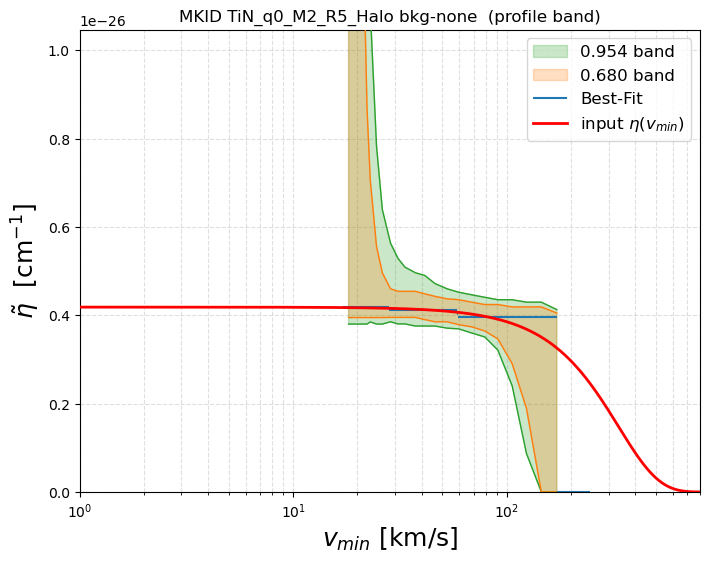

In [6]:
bands = pointwise_band(a, n_indices=30, levels=LEVELS,
                       num_pseudo=50, n_pseudo_edge=500, rel_tol=0.02)

save_band_products(a, bands)
band_table(bands)

## 4. Load and display saved bands (no recomputation)

The primary data is `band/band_idx*.json` (one per point).
`load_pointwise_band` restores the same structure that `pointwise_band`
returns, so the table (`band_table`) and the figure
(`plot_flux_with_pointwise_bands`) use exactly the same code as right after
a computation. To switch configurations, just rerun §1.

(`flux_profile_band.csv` is a summary export for external tools — not used here.)


In [ ]:
# Restore from the per-point JSONs under band/ (same structure as pointwise_band returns)
bands = load_pointwise_band(run_dir(a))
print(f'{len(bands)} points loaded from {run_dir(a) / "band"}')

display(band_table(bands))                              # table in cm^-1 (defined in the first cell)
plot_flux_with_pointwise_bands(a, bands, save=False);   # figure (y-axis capped around the best fit)


## 5. Cross-configuration summary

Aggregate every `band/` folder (per-point JSONs) under `results/`.
"median 68% half-width" is a measure of band tightness (relative to the
best fit).


In [ ]:
rows = []
for band_dir in sorted(RESULTS_DIR.glob('*/bkg-*/*/band')):
    bs = load_pointwise_band(band_dir.parent)
    lv = bs[0]['levels'][0]                      # the 68% level
    best = np.array([b['best_fit'] for b in bs])
    lo = np.array([b['band'][lv][0] for b in bs])
    hi = np.array([b['band'][lv][1] for b in bs])
    ok = (best > 0) & np.isfinite(hi)
    half = (hi[ok] - lo[ok]) / 2 / best[ok] * 100
    vmins = [b['vmin_mid'] for b in bs]
    rows.append({
        'run': band_dir.parent.name,
        'detector': band_dir.parts[-4], 'bkg': band_dir.parts[-3].replace('bkg-', ''),
        'points': len(bs),
        'v range [km/s]': f'{min(vmins):.0f}-{max(vmins):.0f}',
        'median 68% half-width': f'{np.median(half):.0f}%',
        'lower edge hits 0': bool((lo == 0).any()),
    })
summary = pd.DataFrame(rows)
display(summary)
print(f'{len(summary)} band runs found under {RESULTS_DIR}')
